<a href="https://colab.research.google.com/github/Juncalbh/03MIAR-Algoritmos-de-optimizacion/blob/main/Trabajo_Pr%C3%A1ctico_Algoritmos_Juncal_Blanco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Modelo
- ¿Como represento el espacio de soluciones?
- ¿Cual es la función objetivo?
- ¿Como implemento las restricciones?

# Algoritmos de optimización - Trabajo Práctico<br>
Nombre y Apellidos: Juncal Blanco Huerta  <br>
Url: https://colab.research.google.com/drive/1ATCybZPKrQbfqtFDXIixj11Euzd5-_CO?usp=sharing<br>
Google Colab: https://github.com/Juncalbh/03MIAR-Algoritmos-de-optimizacion <br>


# Descripción del Problema:
>1. Sesiones de doblaje <br>




Se precisa coordinar el doblaje de una película. Los actores del doblaje deben coincidir en
las tomas en las que sus personajes aparecen juntos en las diferentes tomas. Los actores de
doblaje cobran todos la misma cantidad por cada día que deben desplazarse hasta el
estudio de grabación independientemente del número de tomas que se graben. No es
posible grabar más de 6 tomas por día. El objetivo es planificar las sesiones por día de
manera que el gasto por los servicios de los actores de doblaje sea el menor posible. Los
datos son:
Número de actores: 10
Número de tomas : 30
Actores/Tomas : https://bit.ly/36D8IuK
- 1 indica que el actor participa en la toma
- 0 en caso contrario



## Idea general de resolución

Para abordar el problema es necesario tener en cuenta varias características estructurales que influyen en la elección de la técnica de resolución.

En primer lugar, las decisiones son **discretas**, ya que cada toma debe asignarse a un único día de grabación. Además, existen **restricciones combinatorias claras**, como el límite de tomas por día, que deben cumplirse en cualquier solución válida.

Por otro lado, el coste depende de **combinaciones de actores presentes cada día**, lo que introduce dependencias entre las decisiones. Esto hace que pequeñas modificaciones en la planificación puedan afectar al coste total.

Finalmente, el número de configuraciones posibles es muy elevado, por lo que **no resulta viable explorar todas las soluciones por enumeración**.

Por estas razones, el problema se modela mediante **variables binarias** que representan la asignación de tomas a días y la presencia de actores en cada jornada. A partir de ellas se define una **función objetivo** que minimiza el número total de **actor-días**, es decir, el número total de días en los que los actores deben acudir al estudio.
  

# Solución — Organizar sesiones de doblaje

## 1. Representación del espacio de soluciones

Una solución consiste en asignar cada una de las **30 tomas** a un día de grabación.

Si denotamos por $d_t$ el día asignado a la toma $t$, una solución puede representarse como:

$$
S = (d_1, d_2, \dots, d_{30})
$$

donde cada $d_t$ indica el día en el que se graba la toma $t$.

En el modelo exacto esta idea se representa mediante variables binarias:

$$
x_{t,d} =
\begin{cases}
1 & \text{si la toma } t \text{ se graba el día } d \\
0 & \text{en caso contrario}
\end{cases}
$$

Además, se definen variables auxiliares para indicar si un actor debe acudir un día dado:

$$
y_{a,d} =
\begin{cases}
1 & \text{si el actor } a \text{ trabaja el día } d \\
0 & \text{en caso contrario}
\end{cases}
$$

y una variable para señalar si un día está siendo utilizado:

$$
z_d =
\begin{cases}
1 & \text{si el día } d \text{ contiene al menos una toma} \\
0 & \text{en caso contrario}
\end{cases}
$$



## 2. Función objetivo

Cada actor cobra por **día de asistencia**, no por número de tomas.  
Por tanto, el coste total viene dado por la suma de actores que acuden cada día:

$$
\min \sum_{d}\sum_{a} y_{a,d}
$$

Esta función objetivo minimiza directamente el número total de **actor-días**.



## 3. Restricciones

### 3.1 Cada toma debe grabarse exactamente una vez

$$
\sum_d x_{t,d} = 1 \qquad \forall t
$$


### 3.2 No se pueden grabar más de 6 tomas por día

$$
\sum_t x_{t,d} \leq 6 \qquad \forall d
$$


### 3.3 Un actor cuenta en un día si participa en alguna toma de ese día

Si el actor $a$ aparece en la toma $t$, y la toma $t$ se asigna al día $d$, entonces ese actor debe contabilizarse ese día:

$$
y_{a,d} \ge x_{t,d} \cdot P_{t,a}
$$

donde $P_{t,a}$ vale 1 si el actor $a$ participa en la toma $t$, y 0 en caso contrario.


### 3.4 Activación de días

Si un día contiene tomas, dicho día debe marcarse como usado:

$$
\sum_t x_{t,d} \le 6 z_d \qquad \forall d
$$

Esta restricción no es imprescindible para el objetivo, pero ayuda a estructurar el modelo y mejora su interpretación.



## 4. Elección del modelo

El problema queda formulado como un problema de **optimización combinatoria con variables binarias**, donde las decisiones son discretas y las restricciones pueden expresarse de forma natural mediante relaciones entre variables.

Este tipo de estructura es habitual en problemas de **planificación y asignación**, donde es necesario decidir cómo distribuir elementos (en este caso, tomas) en recursos limitados (días de grabación) cumpliendo diversas restricciones.

Por este motivo se utiliza **CP-SAT**, un solver diseñado para resolver problemas de **programación entera y satisfacción de restricciones**. Este tipo de herramientas resulta especialmente adecuado cuando el modelo contiene muchas **variables binarias**, **restricciones combinatorias** y dependencias entre decisiones.

Además, CP-SAT combina técnicas de **propagación de restricciones, búsqueda en espacios combinatorios y optimización entera**, lo que permite explorar de forma eficiente espacios de soluciones muy grandes y encontrar soluciones óptimas sin necesidad de enumerar todas las configuraciones posibles.

In [1]:
!pip install -q ortools==9.15.6755

# Respuesta

A continuación se cargan y limpian los datos de la matriz tomas-actores, que será la base del modelo

In [2]:
import pandas as pd
import numpy as np
from ortools.sat.python import cp_model
import matplotlib.pyplot as plt


url = "https://docs.google.com/spreadsheets/d/e/2PACX-1vRh-Ag0aHHBkzKgYm-rnk9crgWGR0ar2BVxSM5A8VUJEtwiGoJfja89Rj3nTstSJ00Q23LrqXGGWAf3/pub?gid=0&single=true&output=csv"

df = pd.read_csv(url, header=0, index_col=0)

print("Leído:", df.shape)
display(df.head())

Leído: (33, 12)


,Actor,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
Toma,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,10.0,NaN,Total
1,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,5
2,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3
3,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,NaN,3
4,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,4


In [3]:

# 1) Quitar columnas totalmente vacías
df = df.dropna(axis=1, how="all")

# 2) LIMPIAR ÍNDICE primero (tomas)
idx = pd.to_numeric(df.index, errors="coerce")
mask = idx.notna() & np.isfinite(idx)
df = df.loc[mask].copy()
df.index = idx[mask].astype(int)

# quedarnos con tomas 1..30
df = df[(df.index >= 1) & (df.index <= 30)].sort_index()

print("Tras limpiar tomas:", df.shape)

# 3) Convertir datos a numérico (ya sin filas basura)
df_num = df.apply(pd.to_numeric, errors="coerce")

# 4) Eliminar la columna Total:
#    En tu caso típico es 'Total' o 'Unnamed: 12' (y suele contener >1)
cols_to_drop = []

# por nombre
for c in df_num.columns:
    name = str(c).strip().lower()
    if name == "total":
        cols_to_drop.append(c)

# por contenido (>1)
for c in df_num.columns:
    s = df_num[c].dropna()
    if not s.empty and (s > 1).any():
        # probable total
        cols_to_drop.append(c)

cols_to_drop = list(dict.fromkeys(cols_to_drop))  # quitar duplicados manteniendo orden
df_num = df_num.drop(columns=cols_to_drop, errors="ignore")

print("Columnas eliminadas (Total):", cols_to_drop)
print("Columnas restantes:", list(df_num.columns))

# 5) Ahora debemos tener 10 columnas: Actor (actor1) + 9 Unnamed
#    Conservamos 'Actor' y renombramos columnas para que queden Actor_1..Actor_10
df_ok = df_num.copy()

# 'Actor' es el actor 1
if "Actor" in df_ok.columns:
    df_ok = df_ok.rename(columns={"Actor": "Actor_1"})
else:
    # Si no existe, lo avisamos
    print("o encuentro columna 'Actor'. Columnas:", list(df_ok.columns))

unnamed = [c for c in df_ok.columns if str(c).startswith("Unnamed:")]
unnamed_sorted = sorted(unnamed, key=lambda x: int(str(x).split(":")[1].strip()))
unnamed_sorted = unnamed_sorted[:9]  # Actor_2..Actor_10

rename_map = {c: f"Actor_{i}" for i, c in enumerate(unnamed_sorted, start=2)}
df_ok = df_ok.rename(columns=rename_map)

# quedarnos con Actor_1..Actor_10 (las que existan)
actor_cols = [f"Actor_{i}" for i in range(1, 11)]
df_ok = df_ok[[c for c in actor_cols if c in df_ok.columns]]

print("Antes de binarizar:", df_ok.shape, "cols:", list(df_ok.columns))

# 6) Convertir a binario int (0/1)
df_ok = df_ok.fillna(0)
df_ok = (df_ok != 0).astype(int)

print("MATRIZ FINAL:", df_ok.shape)
display(df_ok.head())

P = df_ok.to_numpy(dtype=int)
print("Valores únicos:", np.unique(P))
assert df_ok.shape == (30,10), f"Esperaba (30,10) y tengo {df_ok.shape}"

Tras limpiar tomas: (30, 11)
Columnas eliminadas (Total): ['Unnamed: 12']
Columnas restantes: ['Actor', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4', 'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10']
Antes de binarizar: (30, 10) cols: ['Actor_1', 'Actor_2', 'Actor_3', 'Actor_4', 'Actor_5', 'Actor_6', 'Actor_7', 'Actor_8', 'Actor_9', 'Actor_10']
MATRIZ FINAL: (30, 10)


,Actor_1,Actor_2,Actor_3,Actor_4,Actor_5,Actor_6,Actor_7,Actor_8,Actor_9,Actor_10
1,1,1,1,1,1,0,0,0,0,0
2,0,0,1,1,1,0,0,0,0,0
3,0,1,0,0,1,0,1,0,0,0
4,1,1,0,0,0,0,1,1,0,0
5,0,1,0,1,0,0,0,1,0,0


Valores únicos: [0 1]


In [4]:
# Aplicamos CP_MODEL

P = P  # matriz 30x10 ya creada
T = range(P.shape[0])   # 0..29
A = range(P.shape[1])   # 0..9
D = range(30)           # máximo 30 días (cota superior)

model = cp_model.CpModel()

x = {(t,d): model.NewBoolVar(f"x_t{t}_d{d}") for t in T for d in D}  # toma t en día d
y = {(a,d): model.NewBoolVar(f"y_a{a}_d{d}") for a in A for d in D}  # actor a trabaja día d
z = {d: model.NewBoolVar(f"z_d{d}") for d in D}                      # día d usado

# 1) Cada toma exactamente un día
for t in T:
    model.Add(sum(x[(t,d)] for d in D) == 1)

# 2) Máximo 6 tomas por día + activar día
for d in D:
    model.Add(sum(x[(t,d)] for t in T) <= 6)
    model.Add(sum(x[(t,d)] for t in T) <= 6 * z[d])
    for a in A:
        model.Add(y[(a,d)] <= z[d])

# 3) Activación de actor si hay alguna toma suya ese día
for t in T:
    for a in A:
        if P[t, a] == 1:
            for d in D:
                model.Add(y[(a,d)] >= x[(t,d)])

# 4) Romper simetría (días usados al principio)
for d in range(29):
    model.Add(z[d] >= z[d+1])

# Objetivo: minimizar actor-días
model.Minimize(sum(y[(a,d)] for a in A for d in D))

solver = cp_model.CpSolver()
solver.parameters.max_time_in_seconds = 30
solver.parameters.num_search_workers = 8

status = solver.Solve(model)
print("Status:", solver.StatusName(status))
print("Coste óptimo (actor-días):", solver.ObjectiveValue())
print("Días usados:", sum(solver.Value(z[d]) for d in D))


Status: FEASIBLE
Coste óptimo (actor-días): 27.0
Días usados: 30


Tomas asignadas: 30 Únicas: 30
¿Faltan tomas? set()
¿Sobran tomas? set()
Días que violan capacidad (>6): []
Coste por y (objetivo): 27
ObjectiveValue(): 27.0

CALENDARIO ÓPTIMO (sin días vacíos)


,Día,Tomas,Nº tomas,Actores,Nº actores
0,1,"8, 12, 16, 22, 25, 30",6,"1, 2, 3, 4, 6, 10",6
1,2,"3, 4, 10, 15, 21, 29",6,"1, 2, 5, 6, 7, 8, 9",7
2,3,"1, 2, 5, 11, 20, 26",6,"1, 2, 3, 4, 5, 8, 9",7
3,4,"6, 7, 9, 13, 27, 28",6,"1, 2, 4, 5",4
4,5,"14, 17, 18, 19, 23, 24",6,"1, 3, 6",3


Coste por unión (actor-días): 27


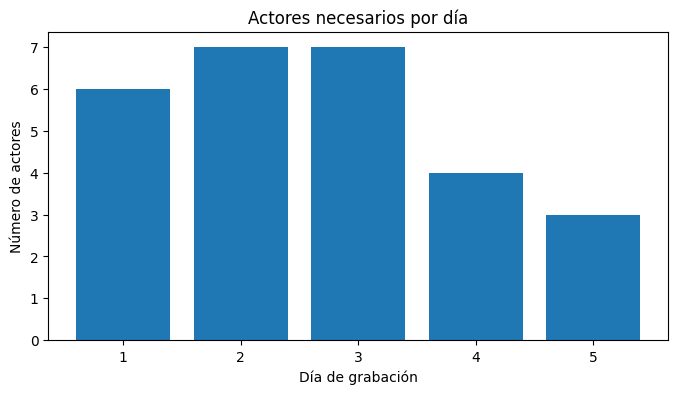

In [5]:

# 1) Recoger asignación toma -> día
take_day = {}
for t in T:
    assigned = [d for d in D if solver.Value(x[(t, d)]) == 1]
    if len(assigned) != 1:
        print("Toma", t + 1, "tiene asignaciones:", assigned)
    else:
        take_day[t] = assigned[0]

# 2) Construir calendario solo con días que tengan tomas
calendar = {}
for t, d in take_day.items():
    calendar.setdefault(d, []).append(t)

# ordenar días y tomas
for d in calendar:
    calendar[d] = sorted(calendar[d])
days_sorted = sorted(calendar.keys())

# 3) Auditorías
all_takes = sorted([t for takes in calendar.values() for t in takes])
print("Tomas asignadas:", len(all_takes), "Únicas:", len(set(all_takes)))
print("¿Faltan tomas?", set(T) - set(all_takes))
print("¿Sobran tomas?", set(all_takes) - set(T))

viol = [d for d in days_sorted if len(calendar[d]) > 6]
print("Días que violan capacidad (>6):", viol)

cost_y = sum(solver.Value(y[(a, d)]) for a in A for d in D)
print("Coste por y (objetivo):", cost_y)
print("ObjectiveValue():", solver.ObjectiveValue())

# 4) Función auxiliar: actores por conjunto de tomas
def union_actors(takes):
    actors = set()
    for t in takes:
        actors |= set(np.where(P[t] == 1)[0])
    return sorted(actors)

# 5) Construir tabla resumen del calendario
rows = []
cost_union = 0

for i, d in enumerate(days_sorted, start=1):
    takes = calendar[d]
    actors = union_actors(takes)
    cost_union += len(actors)

    rows.append({
        "Día": i,
        "Tomas": ", ".join(str(t + 1) for t in takes),
        "Nº tomas": len(takes),
        "Actores": ", ".join(str(a + 1) for a in actors),
        "Nº actores": len(actors)})

df_calendar = pd.DataFrame(rows)

print("\nCALENDARIO ÓPTIMO (sin días vacíos)")
display(df_calendar)

print("Coste por unión (actor-días):", cost_union)

# 6) Gráfico: número de actores por día
plt.figure(figsize=(8, 4))
plt.bar(df_calendar["Día"], df_calendar["Nº actores"])
plt.xlabel("Día de grabación")
plt.ylabel("Número de actores")
plt.title("Actores necesarios por día")
plt.xticks(df_calendar["Día"])
plt.show()



## Análisis del resultado y valoración del enfoque

Tras ejecutar el modelo con CP-SAT se obtiene una planificación de **5 días de grabación** en la que se distribuyen las 30 tomas, cumpliendo todas las restricciones definidas en el modelo. De esta manera logramos minimizar el coste de las sesiones de doblaje y cumplir con el objetivo.

### Verificación de la solución

Los resultados muestran que:

- Las 30 tomas están asignadas exactamente una vez.
- No faltan ni sobran tomas.
- Ningún día supera el límite de 6 tomas, por lo que se respeta la restricción de capacidad.
- Los actores aparecen únicamente en los días en los que participan en alguna toma.

Por tanto, la solución obtenida es **factible y consistente con el modelo planteado**.

### Valor de la función objetivo

El solver devuelve un coste total de **27 actor-días**, que coincide con el valor mostrado por `ObjectiveValue()`.  
Este valor representa el número total de días en los que los actores deben acudir al estudio.

La planificación obtenida agrupa tomas con actores comunes en los mismos días, reduciendo así el número total de asistencias necesarias.

### Complejidad del problema

El problema pertenece a la categoría de **optimización combinatoria**.  
Si se consideran 5 días posibles y 30 tomas, el número teórico de asignaciones posibles sería del orden de:

$$
5^{30}
$$

lo que equivale aproximadamente a:

$$
9.3 \times 10^{20}
$$

configuraciones posibles.

Este tamaño del espacio de soluciones hace inviable cualquier enfoque basado en **enumeración exhaustiva**.

### Adecuación del diseño del modelo

El modelo formulado representa directamente los elementos clave del problema:

- variables binarias para la **asignación de tomas a días**
- variables para representar la **presencia de actores por día**
- restricciones que reflejan las **limitaciones operativas del estudio**

Esta formulación permite expresar el problema de forma clara y estructurada, separando decisiones, restricciones y función objetivo.

### Adecuación de la técnica utilizada

El solver **CP-SAT** resulta especialmente adecuado porque está diseñado para problemas con:

- muchas **variables binarias**
- **restricciones combinatorias**
- espacios de búsqueda muy grandes.

En lugar de explorar todas las soluciones posibles, el solver utiliza técnicas como:

- **propagación de restricciones**
- **poda del espacio de búsqueda**
- **búsqueda guiada por la función objetivo**

Esto permite descartar grandes conjuntos de soluciones inviables o subóptimas y concentrar la exploración en las regiones más prometedoras del espacio de soluciones.

### Conclusión

El enfoque adoptado permite resolver de forma eficiente un problema con un espacio de soluciones extremadamente grande.  
La solución obtenida cumple todas las restricciones del modelo y minimiza el número total de actor-días, lo que confirma que **el diseño del modelo y la técnica de resolución elegida son adecuados para este tipo de problema de planificación combinatoria**.

## Referencias

- Google OR-Tools. *CP-SAT Solver Documentation*.  
  https://developers.google.com/optimization

- Wolsey, L. A. (1998). *Integer Programming*. Wiley.

**Herramientas utilizadas**

- Python (NumPy, Pandas, Matplotlib) y Google Colab para la implementación y visualización.
- Asistencia de un modelo de lenguaje (ChatGPT, OpenAI) para apoyo en la redacción y revisión del trabajo.